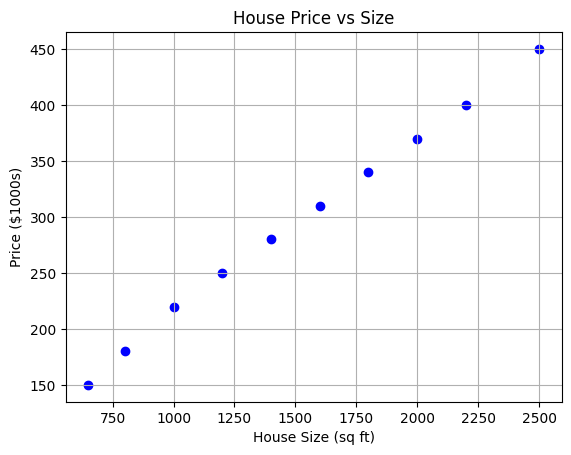

Number of examples: 10
Average size: 1515 sq ft
Average price: $295k


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Simple house price dataset
# Feature: Size in square feet
# Target: Price in thousands of dollars

size = np.array([650, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500])
price = np.array([150, 180, 220, 250, 280, 310, 340, 370, 400, 450])

# Visualize
plt.scatter(size, price, color='blue', marker='o')
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($1000s)')
plt.title('House Price vs Size')
plt.grid(True)
plt.show()

print(f"Number of examples: {len(size)}")
print(f"Average size: {np.mean(size):.0f} sq ft")
print(f"Average price: ${np.mean(price):.0f}k")

In [17]:
def linear_model(x, w, b): 
    """
    Computes the linear model 
    Args:
      x (scalar): Input to the model (Size) 
      y (scalar): Label (Price)
    Returns
      f (scalar): The prediction of the model  
     """
    
    f = x * w + b
    return f 

In [45]:
def cost_function(x, y, w, b):
    """
    Computes the cost function
    Args:
      x (scalar): Input to the model (Size) 
      y (scalar): Label (Price)
      w, b (scalar): Parameters of the model  
    Returns
      cost (scalar): The cost (difference between real y and prediction)
     """
    cost = (linear_model(x,w,b) - y) ** 2
    return cost

In [63]:
def cost_total_function (x, y, w, b):
    """
    Computes the total cost function for all dataset
    Args:
      x (ndarray): Shape (m,) Input to the model (Size) 
      y (ndarray): Shape (m,) Label (Price)
      w, b (scalar): Parameters of the model  
    Returns
      cost_total (scalar): The total cost (difference between real y and prediction)
     """

    # Number of elements to cycle through
    m = len(x)
    total_cost = 0

    for i in range (m):
        total_cost = total_cost + cost_function(x[i], y[i], w, b)
    total_cost = total_cost/2 * m

    return total_cost
        


In [47]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = len(x)
    
    dj_dw = 0
    dj_db = 0
    
    for i in range (m):
        dj_db = dj_db + ((w * x[i] + b) - y[i])
        dj_dw = dj_dw + (((w * x[i] + b) - y[i]) * x[i])
    
    dj_db = dj_db/m
    dj_dw = dj_dw/m 
    
    return dj_dw, dj_db

In [65]:
def gradient_descent(x, y, w, b, learning_rate, num_iters): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
      learning_rate (scalar): learning rate used to update w and b
      num_iters (scalar): Limit to the number of iteration
    Returns
      w: the selected value for w
      b: the selected value for b
     """

    for i in range (num_iters):
        total_cost = cost_total_function (x, y, w, b)
        print(f"total_cost: {total_cost}")
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - learning_rate * dj_dw           
        b = b - learning_rate * dj_db

    return w,b

total_cost: 50.00000000000001
total_cost: 40.518189173333
total_cost: 32.83792240373272
total_cost: 26.6169063203565
total_cost: 21.57788329282176
total_cost: 17.496274640518617
total_cost: 14.190171632153072
total_cost: 11.512228195376984
total_cost: 9.343094011588349
total_cost: 7.58609532271956
total_cost: 6.162926384735837
total_cost: 5.010159544969022
total_cost: 4.0764184047579
total_cost: 3.320088081186894
total_cost: 2.707460519094378
total_cost: 2.211232193799442
total_cost: 1.8092872503105428
total_cost: 1.4837118460845342
total_cost: 1.2199957686614677
total_cost: 1.0063857459487826
total_cost: 0.8333616275515079
total_cost: 0.693212091649716
total_cost: 0.5796909675692643
total_cost: 0.48773885706409825
total_cost: 0.4132576475549143
total_cost: 0.3529278678524751
total_cost: 0.3040607462934992
total_cost: 0.2644783778307287
total_cost: 0.23241665937588457
total_cost: 0.20644666742746082
total_cost: 0.18541097394923772
total_cost: 0.1683720622318768
total_cost: 0.1545705437

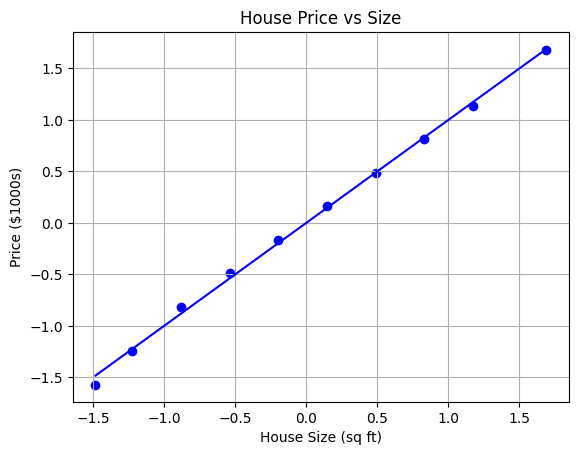

In [66]:
w = 0
b = 0

# Scale the features
scaler_x = StandardScaler()
scaler_y = StandardScaler()

size_scaled = scaler_x.fit_transform(size.reshape(-1, 1)).flatten()
price_scaled = scaler_y.fit_transform(price.reshape(-1, 1)).flatten()

w, b = gradient_descent (size_scaled, price_scaled, w, b, 0.1, 1000)

m = size.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * size_scaled[i] + b

# Plot the linear fit
plt.plot(size_scaled, predicted, c = "b")

plt.scatter(size_scaled, price_scaled, color='blue', marker='o')
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($1000s)')
plt.title('House Price vs Size')
plt.grid(True)
plt.show()